# Brain Computer Interface Notebook 

### Features 
- Click
- Rest

Trained using Scikit-Learn Machine Learning Package.

In [1]:
!pip install scikit-learn pandas numpy matplotlib warnings scipy

ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for warnings


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Constant values
FS = 256 # sampling rate (Hz)
CLASS_NAMES = {0: 'REST', 1: 'CLICK'}
LABEL_ORDER = [0, 1]
COLORS      = {0: '#00C896', 1: '#4A9EFF'}

## Load and Preview EEG Recorded Data

In [17]:
df = pd.read_csv('eeg_precision_bci.csv')
df.head()

,Timestamp_Unix,Timestamp_Ms,Signal_Raw,Intent_Label,Label_Class
0,1.771771e+09,6.849,500.0000,REST,0
1,1.771771e+09,14.548,1091.3769,REST,0
2,1.771771e+09,18.485,1192.5310,REST,0
3,1.771771e+09,26.508,1117.0195,REST,0
4,1.771771e+09,30.363,1019.7588,REST,0


In [18]:
# remove the first 500 records (first 2 sec)
df = df.iloc[500:].reset_index(drop=True)

In [19]:
signal = df['Signal_Raw'].values - 500.0 # normalize the data to 0 mV
labels_raw = df['Label_Class'].values
labels_raw

array([1, 1, 1, ..., 1, 1, 1])

In [20]:
print(f"Total samples: {len(signal)}")
print(f"Total duration: {len(signal)/FS:.1f} seconds")
print(f"Classes: {dict(zip(*np.unique(labels_raw, return_counts=True)))}")

Total samples: 44601
Total duration: 174.2 seconds
Classes: {0: 19041, 1: 25560}


In [21]:
df.head()

,Timestamp_Unix,Timestamp_Ms,Signal_Raw,Intent_Label,Label_Class
0,1.771771e+09,3082.343,-351.7209,CLICK,1
1,1.771771e+09,3089.620,-374.6305,CLICK,1
2,1.771771e+09,3094.769,-330.0345,CLICK,1
3,1.771771e+09,3101.969,-330.4856,CLICK,1
4,1.771771e+09,3107.113,-351.7369,CLICK,1


## Visualise first 30 seconds of EEG with label overlay

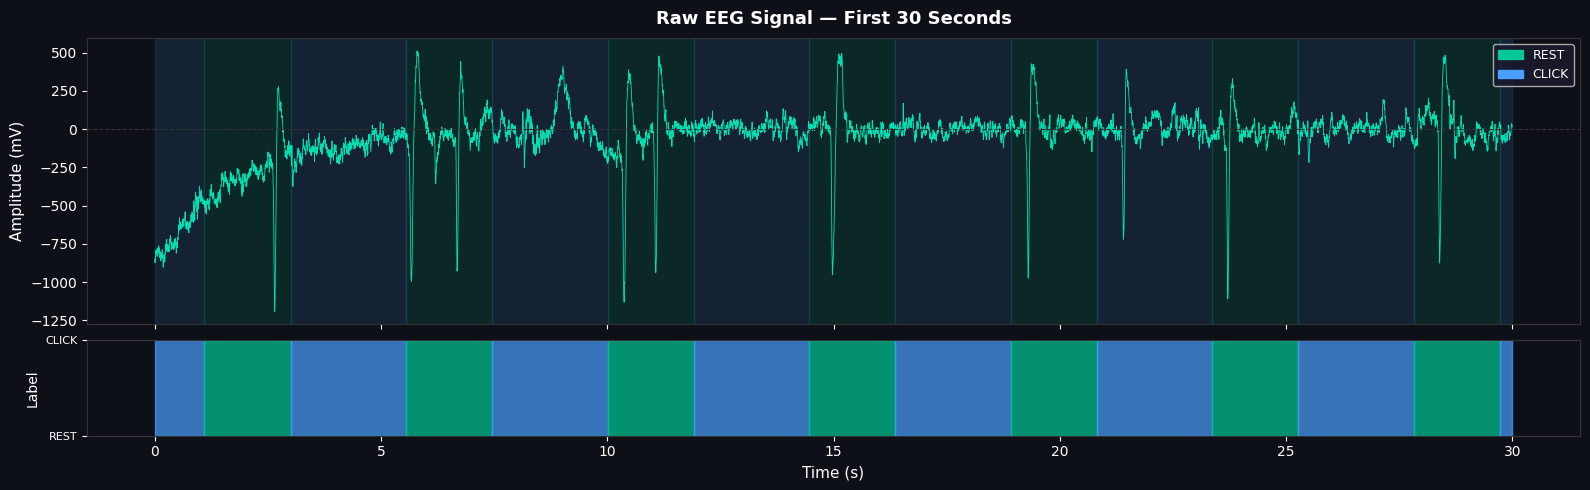

In [22]:
t = np.arange(len(signal)) / FS
window = int(30 * FS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0D1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white'); ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values(): spine.set_color('#333')

ax1.plot(t[:window], signal[:window], color='#00F5C4', lw=0.6, alpha=0.9)
ax1.set_ylabel('Amplitude (mV)', color='white', fontsize=11)
ax1.set_title('Raw EEG Signal — First 30 Seconds', color='white', fontsize=13, fontweight='bold', pad=10)
ax1.axhline(0, color='#333', lw=0.8, ls='--')

# Label background shading
prev_lbl = labels_raw[0]; start_t = 0
for i in range(1, window):
    if labels_raw[i] != prev_lbl or i == window-1:
        c = COLORS[prev_lbl]
        ax1.axvspan(t[start_t], t[i], alpha=0.12, color=c)
        ax2.axvspan(t[start_t], t[i], alpha=0.7,  color=c)
        prev_lbl = labels_raw[i]; start_t = i

ax2.set_yticks([0, 5])
ax2.set_yticklabels(['REST', 'CLICK'], color='white', fontsize=8)
ax2.set_ylabel('Label', color='white', fontsize=10)
ax2.set_xlabel('Time (s)', color='white', fontsize=11)

from matplotlib.patches import Patch
patches = [Patch(color=COLORS[c], label=CLASS_NAMES[c]) for c in LABEL_ORDER]
ax1.legend(handles=patches, loc='upper right', facecolor='#1A1A2E', labelcolor='white', fontsize=9)

plt.tight_layout(h_pad=0.5)
plt.show()

## Trial Segmentation

In [23]:
# Detect exact label transitions → each continuous run = one BCI trial
transitions = np.where(np.diff(labels_raw) != 0)[0] + 1
boundaries  = np.concatenate([[0], transitions, [len(labels_raw)]])

segments = []
for i in range(len(boundaries) - 1):
    start, end = int(boundaries[i]), int(boundaries[i+1])
    lbl = labels_raw[start]
    seg = signal[start:end]
    if len(seg) >= 128:                     # skip very short fragments
        segments.append((seg, int(lbl)))

print(f"Total trials detected : {len(segments)}")
from collections import Counter
dist = Counter(s[1] for s in segments)
for cls, cnt in sorted(dist.items()):
    print(f"  Class {cls} ({CLASS_NAMES[cls]:5s}): {cnt} trials, "
          f"avg {np.mean([len(s[0]) for s in segments if s[1]==cls]):.0f} samples "
          f"({np.mean([len(s[0]) for s in segments if s[1]==cls])/FS:.1f}s)")


Total trials detected : 79
  Class 0 (REST ): 39 trials, avg 488 samples (1.9s)
  Class 1 (CLICK): 40 trials, avg 639 samples (2.5s)


## Feature Engineering 
#### 42 Features per Trial

In [24]:
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid

In [25]:
# ── Feature Engineering — 42 Features per Trial ───────────
FEATURE_NAMES = []

def band_power(f, pxx, lo, hi):
    idx = (f >= lo) & (f <= hi)
    return trapezoid(pxx[idx], f[idx]) if idx.sum() > 0 else 0.0

def spectral_entropy(pxx):
    p = pxx / (pxx.sum() + 1e-10)
    return float(-np.sum(p * np.log2(p + 1e-10)))

def hjorth_params(x):
    d1 = np.diff(x); d2 = np.diff(d1)
    act  = float(np.var(x))
    mob  = float(np.sqrt(np.var(d1) / (act  + 1e-10)))
    comp = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10))
    return act, mob, comp

def extract_features(ep):
    nperseg = min(128, len(ep))
    d1 = np.diff(ep)
    half = len(ep) // 2

    # ── Time-domain (18 features) ───────────────────────────
    td = [
        float(np.mean(ep)),          # mean amplitude
        float(np.std(ep)),           # standard deviation
        float(np.var(ep)),           # variance
        float(skew(ep)),             # skewness
        float(kurtosis(ep)),         # excess kurtosis
        float(np.sqrt(np.mean(ep**2))),           # RMS
        float(np.max(ep) - np.min(ep)),           # peak-to-peak
        float(np.mean(np.abs(ep))),               # mean absolute value
        float(np.sum(np.diff(np.sign(ep)) != 0)), # zero-crossing rate
        float(np.percentile(ep, 10)),             # 10th pctile
        float(np.percentile(ep, 25)),             # 25th pctile
        float(np.percentile(ep, 75)),             # 75th pctile
        float(np.percentile(ep, 90)),             # 90th pctile
        float(np.sum(np.abs(d1))),                # line length (complexity proxy)
        float(np.mean(ep[:half])),                # first-half mean
        float(np.mean(ep[half:])),                # second-half mean
        float(np.std(ep[:half])),                 # first-half std
        float(np.std(ep[half:])),                 # second-half std
    ]

    # ── Hjorth parameters (3 features) ─────────────────────
    act, mob, comp = hjorth_params(ep)
    hj = [act, mob, comp]

    # ── Autocorrelation lags (5 features) ──────────────────
    ac = np.correlate(ep, ep, mode='full')
    ac = ac[len(ac)//2:]
    ac = ac / (ac[0] + 1e-10)
    autocorr = [float(ac[lag]) if lag < len(ac) else 0.0
                for lag in [1, 2, 5, 10, 20]]

    # ── Frequency-domain — Welch PSD (16 features) ─────────
    f, pxx = welch(ep, fs=FS, nperseg=nperseg)
    pxx = np.maximum(pxx, 1e-12)

    d_ = band_power(f, pxx, 2,  4)    # delta
    t_ = band_power(f, pxx, 4,  8)    # theta
    a_ = band_power(f, pxx, 8,  13)   # alpha
    b_ = band_power(f, pxx, 13, 30)   # beta
    g_ = band_power(f, pxx, 30, 45)   # gamma
    tot= band_power(f, pxx, 1,  50)   # total

    fd = [
        d_, t_, a_, b_, g_, tot,              # absolute band powers
        d_/(tot+1e-10),                        # relative delta
        t_/(tot+1e-10),                        # relative theta
        a_/(tot+1e-10),                        # relative alpha
        b_/(tot+1e-10),                        # relative beta
        a_ /(b_ +1e-10),                       # alpha/beta ratio (key MI feature)
        t_ /(a_ +1e-10),                       # theta/alpha ratio
        (a_+b_)/(d_+t_+1e-10),                # high/low ratio
        spectral_entropy(pxx),                 # spectral entropy
        float(f[np.argmax(pxx)]),              # peak frequency
        float(np.sum(pxx * f) / (np.sum(pxx)+1e-10)),  # spectral centroid
    ]

    return np.array(td + hj + autocorr + fd, dtype=np.float32)

# Build global feature name list
FEATURE_NAMES = (
    ['mean','std','var','skewness','kurtosis','rms','p2p','mav','zcr',
     'pct10','pct25','pct75','pct90','line_len','h1_mean','h2_mean','h1_std','h2_std']
  + ['hjorth_activity','hjorth_mobility','hjorth_complexity']
  + [f'autocorr_lag{l}' for l in [1,2,5,10,20]]
  + ['delta','theta','alpha','beta','gamma','total_power',
     'rel_delta','rel_theta','rel_alpha','rel_beta',
     'alpha_beta_ratio','theta_alpha_ratio','hilo_ratio',
     'spectral_entropy','peak_freq','spectral_centroid']
)

X = np.array([extract_features(s[0]) for s in segments])
y = np.array([s[1] for s in segments])

print(f"Feature matrix shape: {X.shape}  (trials × features)")
print(f"Feature names: {len(FEATURE_NAMES)}")
pd.DataFrame(X, columns=FEATURE_NAMES).describe().round(3)


Feature matrix shape: (79, 42)  (trials × features)
Feature names: 42


,mean,std,var,skewness,kurtosis,rms,p2p,mav,zcr,pct10,...,rel_delta,rel_theta,rel_alpha,rel_beta,alpha_beta_ratio,theta_alpha_ratio,hilo_ratio,spectral_entropy,peak_freq,spectral_centroid
count,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,...,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000,79.000
mean,-14.429,105.166,14482.687,-0.931,5.752,115.227,793.580,76.593,69.443,-98.863,...,0.308,0.368,0.128,0.126,2.154,3.270,0.511,3.190,3.595,9.080
std,82.913,58.878,14967.862,1.118,6.312,91.139,476.990,79.802,26.174,102.979,...,0.102,0.101,0.040,0.114,1.801,1.750,0.638,0.610,2.976,3.965
min,-666.581,34.926,1219.839,-3.712,-0.995,35.192,212.147,27.713,0.000,-821.703,...,0.057,0.107,0.020,0.012,0.199,0.749,0.096,2.134,2.000,3.661
25%,-4.385,50.308,2530.917,-1.831,0.244,50.363,315.022,38.437,52.000,-96.843,...,0.247,0.294,0.100,0.040,0.685,2.228,0.212,2.689,2.000,5.455
50%,-0.418,110.931,12305.678,-0.608,2.916,111.498,664.201,61.386,67.000,-70.810,...,0.309,0.386,0.127,0.097,1.417,2.919,0.314,3.043,2.000,8.623
75%,3.268,145.234,21094.124,-0.028,12.051,147.839,1211.212,83.671,90.000,-57.974,...,0.369,0.450,0.160,0.185,3.330,3.976,0.522,3.715,4.000,12.045
max,24.056,254.407,64722.707,1.292,22.545,679.365,1845.535,666.581,117.000,-39.336,...,0.615,0.517,0.231,0.546,8.949,12.479,3.831,4.565,16.000,19.215


## EEG Signal Band Power Distributed per Class

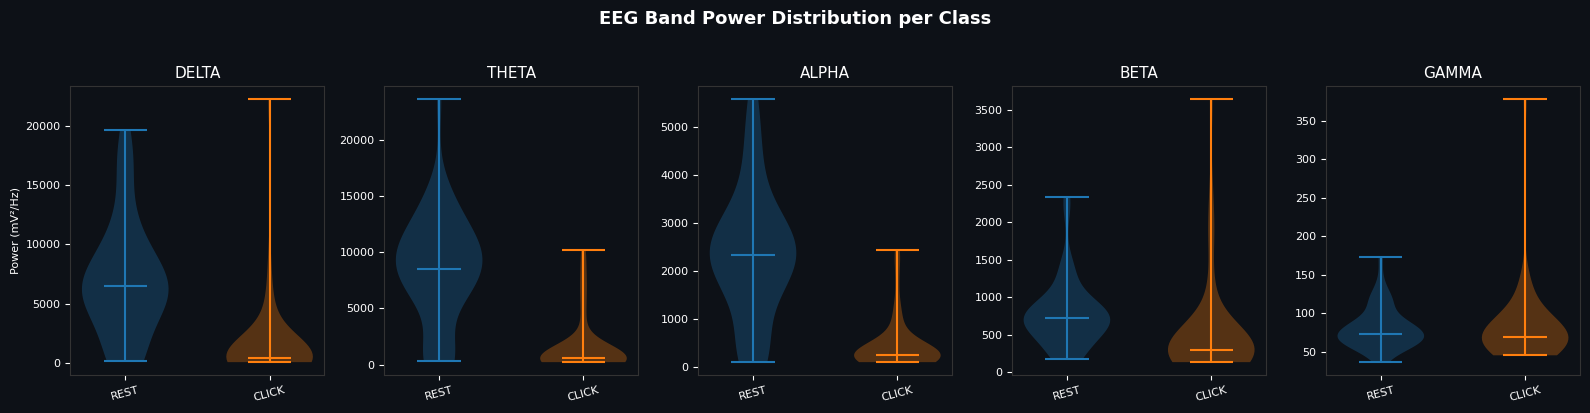

In [26]:
band_cols = ['delta','theta','alpha','beta','gamma']

feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df['Class'] = [CLASS_NAMES[yi] for yi in y]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('EEG Band Power Distribution per Class', color='white', fontsize=13, fontweight='bold', y=1.02)

for ax, band in zip(axes, band_cols):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_color('#333')

    for cls in ['REST', 'CLICK']:
        vals = feat_df[feat_df['Class']==cls][band].values
        c    = list(COLORS.values())[['REST','CLICK'].index(cls)]
        ax.violinplot([vals], positions=[['REST','CLICK'].index(cls)],
                      showmedians=True, widths=0.6)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['REST','CLICK'], rotation=15, fontsize=8, color='white')
    ax.set_title(band.upper(), color='white', fontsize=11)
    ax.set_ylabel('Power (mV²/Hz)' if band=='delta' else '', color='white', fontsize=8)

plt.tight_layout()
plt.show()


# Model Training
### Classification Model

In [27]:
# Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
X_scaled.shape

(79, 42)

In [29]:
# Using Ensemble Classifier Models

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)


### Classification Pipeline

In [30]:
# Using soft-voting ensemble where average predicted probabilities are used

ensemble = VotingClassifier(
    estimators=[('et', et), ('rf', rf)],
    voting='soft',
    n_jobs=-1,
)

In [31]:
ensemble

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

In [32]:
# 5-fold Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble, X_scaled, y, cv=cv, scoring='accuracy')

print("=" * 52)
print("  ExtraTrees + RandomForest Soft Voting Ensemble")
print("=" * 52)
print(f"  Fold accuracies : {[f'{s*100:.1f}%' for s in scores]}")
print(f"  Mean accuracy   : {scores.mean()*100:.1f}%")

  ExtraTrees + RandomForest Soft Voting Ensemble
  Fold accuracies : ['75.0%', '81.2%', '81.2%', '75.0%', '100.0%']
  Mean accuracy   : 82.5%


## Model Evaluation 

In [33]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [34]:
y_pred = cross_val_predict(ensemble, X_scaled, y, cv=cv, method='predict')

print("\nClassification Report:")
print(classification_report(y, y_pred,
      target_names=[CLASS_NAMES[c] for c in LABEL_ORDER],
      labels=LABEL_ORDER))


Classification Report:
              precision    recall  f1-score   support

        REST       0.82      0.82      0.82        39
       CLICK       0.82      0.82      0.82        40

    accuracy                           0.82        79
   macro avg       0.82      0.82      0.82        79
weighted avg       0.82      0.82      0.82        79



#### Plot Confusion Matrix

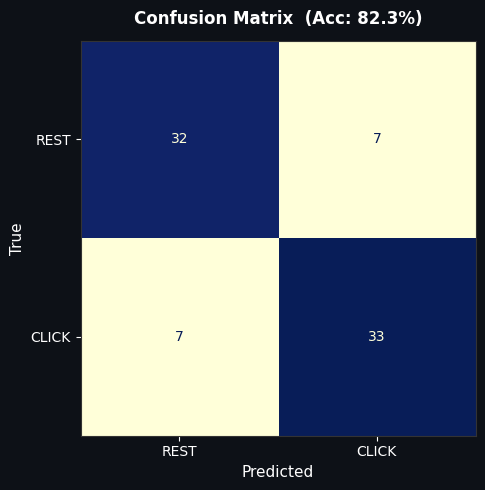

In [35]:
cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in LABEL_ORDER]
)
disp.plot(ax=ax, colorbar=False, cmap='YlGnBu')
ax.set_title(f'Confusion Matrix  (Acc: {accuracy_score(y,y_pred)*100:.1f}%)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', color='white', fontsize=11)
ax.set_ylabel('True',      color='white', fontsize=11)
ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

plt.tight_layout()
plt.show()


## Saving Final Model

In [36]:
import joblib

# Save the model to a file
joblib.dump(ensemble, 'BCI_MODEL.joblib')

print("Model saved successfully!")

Model saved successfully!


In [37]:
# Loading the model
import joblib

# Load the model from the file
loaded_model = joblib.load('BCI_MODEL.joblib')


In [38]:
loaded_model

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

---
# PyTorch Deep Learning Models
Three architectures are implemented:
- **FNN** – Feedforward Neural Network on the 42 engineered features
- **CNN** – 1-D Convolutional Network on the raw EEG segment (fixed-length window)
- **Hybrid CNN + FNN** – CNN processes the raw signal; FNN processes the feature vector; outputs are fused before the final classifier


In [39]:
!pip install torch torchvision --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check for MPS availability, then CUDA, then fallback to CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device set to: {DEVICE}")

Device set to: mps


In [41]:
# ── Shared data preparation ──────────────────────────────────────────────────
# Map labels {0,5} → {0,1} for binary classification
label_map = {0: 0, 1: 1}
y_bin = np.array([label_map[yi] for yi in y], dtype=np.int64)

# ── Feature matrix (already scaled from sklearn section)
X_feat = X_scaled.astype(np.float32)            # (N, 42)
N_FEATURES = X_feat.shape[1]

# ── Raw segments → pad / truncate to a fixed window length
WIN_LEN = 256   # 1 second at 256 Hz

def pad_or_trim(seg, length=WIN_LEN):
    if len(seg) >= length:
        return seg[:length]
    return np.pad(seg, (0, length - len(seg)), mode='constant')

X_raw = np.array([pad_or_trim(s[0]) for s in segments], dtype=np.float32)  # (N, WIN_LEN)

# Z-score each raw window independently
X_raw = (X_raw - X_raw.mean(axis=1, keepdims=True)) / (X_raw.std(axis=1, keepdims=True) + 1e-8)

print(f'Feature matrix : {X_feat.shape}')
print(f'Raw EEG matrix : {X_raw.shape}')
print(f'Labels         : {y_bin.shape}  (classes: {np.unique(y_bin, return_counts=True)})')

Feature matrix : (79, 42)
Raw EEG matrix : (79, 256)
Labels         : (79,)  (classes: (array([0, 1]), array([39, 40])))


In [42]:
# ── Generic cross-validated training & evaluation ───────────────────────────

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        *inputs, labels = [b.to(DEVICE) for b in batch]
        out = model(*inputs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        *inputs, labels = [b.to(DEVICE) for b in batch]
        out = model(*inputs)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)


def cross_validate(build_fn, build_dataset_fn, y_labels,
                   n_splits=5, epochs=80, lr=1e-3, batch_size=16):
    """Run stratified k-fold CV; returns per-fold accuracies + full OOF predictions."""
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof_true, oof_pred = np.zeros(len(y_labels), dtype=int), np.zeros(len(y_labels), dtype=int)
    fold_accs = []
    train_loss_history = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(y_labels)), y_labels)):
        model = build_fn().to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        tr_ds  = build_dataset_fn(tr_idx)
        val_ds = build_dataset_fn(val_idx)
        tr_loader  = DataLoader(tr_ds,  batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        fold_losses = []
        for ep in range(epochs):
            l = train_epoch(model, tr_loader, criterion, optimizer)
            scheduler.step()
            fold_losses.append(l)

        train_loss_history.append(fold_losses)
        true_lbl, pred_lbl = eval_model(model, val_loader)
        acc = accuracy_score(true_lbl, pred_lbl)
        fold_accs.append(acc)
        oof_true[val_idx] = true_lbl
        oof_pred[val_idx] = pred_lbl
        print(f'  Fold {fold+1}/{n_splits}  val_acc={acc*100:.1f}%')

    print(f'  → Mean CV Acc: {np.mean(fold_accs)*100:.1f}% ± {np.std(fold_accs)*100:.1f}%')
    return fold_accs, oof_true, oof_pred, train_loss_history


def plot_results(model_name, fold_accs, oof_true, oof_pred, loss_history, color='#4A9EFF'):
    """Plot training curves, fold accuracies, and confusion matrix."""
    fig = plt.figure(figsize=(16, 4))
    fig.patch.set_facecolor('#0D1117')
    gs = fig.add_gridspec(1, 3, wspace=0.35)

    # --- Loss curves
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor('#0D1117')
    for spine in ax1.spines.values(): spine.set_color('#333')
    ax1.tick_params(colors='white')
    for i, lh in enumerate(loss_history):
        ax1.plot(lh, alpha=0.6, label=f'Fold {i+1}')
    ax1.set_title('Training Loss per Fold', color='white', fontweight='bold')
    ax1.set_xlabel('Epoch', color='white'); ax1.set_ylabel('Loss', color='white')
    ax1.legend(fontsize=7, framealpha=0.2, labelcolor='white')

    # --- Fold accuracies bar
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor('#0D1117')
    for spine in ax2.spines.values(): spine.set_color('#333')
    ax2.tick_params(colors='white')
    bars = ax2.bar(range(1, len(fold_accs)+1), [a*100 for a in fold_accs], color=color, alpha=0.85)
    ax2.axhline(np.mean(fold_accs)*100, color='white', linestyle='--', linewidth=1.2, label=f'Mean={np.mean(fold_accs)*100:.1f}%')
    ax2.set_ylim(0, 110)
    ax2.set_title('CV Fold Accuracies', color='white', fontweight='bold')
    ax2.set_xlabel('Fold', color='white'); ax2.set_ylabel('Accuracy (%)', color='white')
    ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white')
    for bar, acc in zip(bars, fold_accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                 f'{acc*100:.0f}%', ha='center', color='white', fontsize=8)

    # --- Confusion matrix
    ax3 = fig.add_subplot(gs[2])
    ax3.set_facecolor('#0D1117')
    for spine in ax3.spines.values(): spine.set_color('#333')
    ax3.tick_params(colors='white')
    cm = confusion_matrix(oof_true, oof_pred)
    ConfusionMatrixDisplay(cm, display_labels=['REST', 'CLICK']).plot(
        ax=ax3, colorbar=False, cmap='YlGnBu')
    ax3.set_title(f'OOF Confusion Matrix  (Acc: {accuracy_score(oof_true, oof_pred)*100:.1f}%)',
                  color='white', fontweight='bold')
    ax3.set_xlabel('Predicted', color='white'); ax3.set_ylabel('True', color='white')
    ax3.xaxis.set_tick_params(labelcolor='white'); ax3.yaxis.set_tick_params(labelcolor='white')

    fig.suptitle(f'{model_name} — Results', color='white', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(classification_report(oof_true, oof_pred, target_names=['REST', 'CLICK']))

## 1. Feedforward Neural Network (FNN)
Takes the **42 engineered features** as input.  
Architecture: `Linear → BN → ReLU → Dropout` × 3 layers → softmax output.

In [43]:
# ── FNN Architecture ─────────────────────────────────────────────────────────
class BCIFNN(nn.Module):
    def __init__(self, in_features=42, hidden=[128, 64, 32], dropout=0.4, n_classes=2):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Quick architecture summary
demo = BCIFNN()
print(demo)
total_params = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

BCIFNN(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

Trainable parameters: 16,354


In [44]:
# ── FNN Cross-Validation ──────────────────────────────────────────────────────
print('Training FNN (42 engineered features)...')

X_feat_t = torch.tensor(X_feat)          # (N, 42)
y_t = torch.tensor(y_bin)

def fnn_dataset(idx):
    return TensorDataset(X_feat_t[idx], y_t[idx])

fnn_accs, fnn_true, fnn_pred, fnn_loss_hist = cross_validate(
    build_fn      = lambda: BCIFNN(in_features=N_FEATURES),
    build_dataset_fn = fnn_dataset,
    y_labels      = y_bin,
    n_splits=5, epochs=500, lr=1e-3, batch_size=16,
)

Training FNN (42 engineered features)...
  Fold 1/5  val_acc=100.0%
  Fold 2/5  val_acc=93.8%
  Fold 3/5  val_acc=87.5%
  Fold 4/5  val_acc=87.5%
  Fold 5/5  val_acc=100.0%
  → Mean CV Acc: 93.8% ± 5.6%


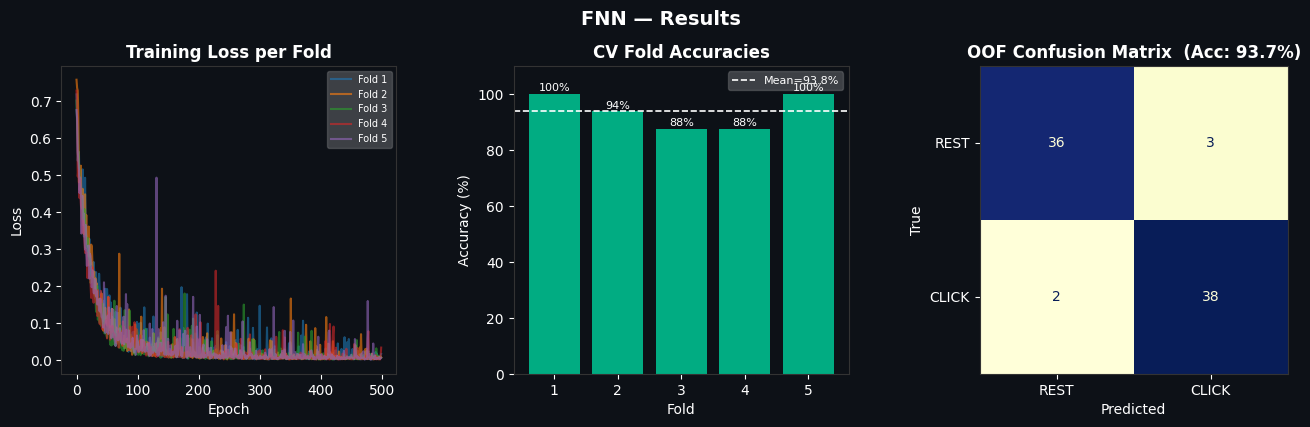

              precision    recall  f1-score   support

        REST       0.95      0.92      0.94        39
       CLICK       0.93      0.95      0.94        40

    accuracy                           0.94        79
   macro avg       0.94      0.94      0.94        79
weighted avg       0.94      0.94      0.94        79



In [45]:
plot_results('FNN', fnn_accs, fnn_true, fnn_pred, fnn_loss_hist, color='#00C896')

## 2. Convolutional Neural Network (CNN)
Takes the **raw EEG window** (256 samples) as a 1-D temporal signal.  
Architecture: Three `Conv1D → BN → ReLU → MaxPool` blocks followed by global average pooling and a linear classifier.

In [46]:
# ── CNN Architecture ──────────────────────────────────────────────────────────
class BCIConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, pool=2, dropout=0.3):
        super().__init__()
        pad = kernel // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.MaxPool1d(pool),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.block(x)


class BCICNN(nn.Module):
    """
    Input shape: (batch, 1, WIN_LEN)
    Three conv blocks downsample the temporal dimension;
    global average pooling collapses to a fixed-size embedding.
    """
    def __init__(self, win_len=256, n_classes=2, dropout=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            BCIConvBlock(1,  32, kernel=15, pool=2, dropout=dropout),  # → (32, 128)
            BCIConvBlock(32, 64, kernel=9,  pool=2, dropout=dropout),  # → (64,  64)
            BCIConvBlock(64, 128,kernel=5,  pool=2, dropout=dropout),  # → (128, 32)
        )
        self.gap = nn.AdaptiveAvgPool1d(1)     # → (128, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, WIN_LEN) → add channel dim
        x = x.unsqueeze(1)          # (B, 1, WIN_LEN)
        x = self.encoder(x)
        x = self.gap(x)
        return self.classifier(x)

    def embed(self, x):
        """Return the 128-d embedding before classification (used by Hybrid)."""
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.gap(x)
        return x.squeeze(-1)        # (B, 128)


demo_cnn = BCICNN()
print(demo_cnn)
print(f'\nTrainable parameters: {sum(p.numel() for p in demo_cnn.parameters() if p.requires_grad):,}')

BCICNN(
  (encoder): Sequential(
    (0): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (1): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (2): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running

In [47]:
# ── CNN Cross-Validation ──────────────────────────────────────────────────────
print('Training CNN (raw EEG windows)...')

X_raw_t = torch.tensor(X_raw)      # (N, WIN_LEN)
y_t     = torch.tensor(y_bin)

def cnn_dataset(idx):
    return TensorDataset(X_raw_t[idx], y_t[idx])

cnn_accs, cnn_true, cnn_pred, cnn_loss_hist = cross_validate(
    build_fn         = lambda: BCICNN(win_len=WIN_LEN),
    build_dataset_fn = cnn_dataset,
    y_labels         = y_bin,
    n_splits=5, epochs=500, lr=5e-4, batch_size=16,
)

Training CNN (raw EEG windows)...
  Fold 1/5  val_acc=75.0%
  Fold 2/5  val_acc=68.8%
  Fold 3/5  val_acc=62.5%
  Fold 4/5  val_acc=81.2%
  Fold 5/5  val_acc=46.7%
  → Mean CV Acc: 66.8% ± 11.9%


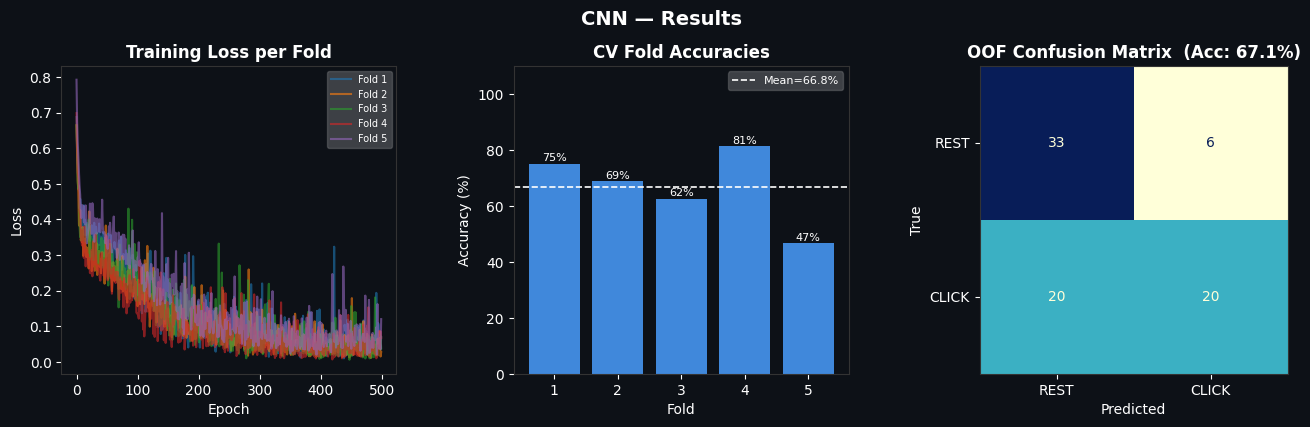

              precision    recall  f1-score   support

        REST       0.62      0.85      0.72        39
       CLICK       0.77      0.50      0.61        40

    accuracy                           0.67        79
   macro avg       0.70      0.67      0.66        79
weighted avg       0.70      0.67      0.66        79



In [48]:
plot_results('CNN', cnn_accs, cnn_true, cnn_pred, cnn_loss_hist, color='#4A9EFF')

## 3. Hybrid CNN + FNN Model
**Dual-branch architecture:**
- **CNN branch** processes the raw EEG window → 128-d temporal embedding
- **FNN branch** processes the 42 engineered features → 64-d feature embedding
- Both embeddings are **concatenated** → final MLP classifier (192-d → 64 → 2)

This lets the model jointly exploit low-level waveform patterns and hand-crafted spectral/time-domain features.

In [49]:
# ── Hybrid Architecture ───────────────────────────────────────────────────────
class BCIHybrid(nn.Module):
    """
    Dual-input model:
      raw_eeg  : (B, WIN_LEN)  → CNN branch  → 128-d
      features : (B, N_FEAT)   → FNN branch  → 64-d
    Combined   : 192-d → classifier → 2 logits
    """
    def __init__(self, win_len=256, n_feat=42, dropout=0.4, n_classes=2):
        super().__init__()

        # --- CNN branch
        self.cnn_branch = nn.Sequential(
            BCIConvBlock(1,  32, kernel=15, pool=2, dropout=dropout),
            BCIConvBlock(32, 64, kernel=9,  pool=2, dropout=dropout),
            BCIConvBlock(64, 128,kernel=5,  pool=2, dropout=dropout),
            nn.AdaptiveAvgPool1d(1),
        )  # → (B, 128, 1)

        # --- FNN branch
        self.fnn_branch = nn.Sequential(
            nn.Linear(n_feat, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )  # → (B, 64)

        # --- Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, raw, feat):
        # CNN path
        cnn_out = self.cnn_branch(raw.unsqueeze(1))  # (B, 128, 1)
        cnn_out = cnn_out.squeeze(-1)                # (B, 128)

        # FNN path
        fnn_out = self.fnn_branch(feat)              # (B, 64)

        # Fusion
        fused = torch.cat([cnn_out, fnn_out], dim=1) # (B, 192)
        return self.fusion(fused)


demo_hybrid = BCIHybrid()
print(demo_hybrid)
print(f'\nTrainable parameters: {sum(p.numel() for p in demo_hybrid.parameters() if p.requires_grad):,}')

BCIHybrid(
  (cnn_branch): Sequential(
    (0): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (1): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(9,), stride=(1,), padding=(4,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.4, inplace=False)
      )
    )
    (2): BCIConvBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_r

In [50]:
# ── Hybrid Cross-Validation ──────────────────────────────────────────────────
print('Training Hybrid CNN+FNN...')

X_raw_t  = torch.tensor(X_raw)     # (N, WIN_LEN)
X_feat_t = torch.tensor(X_feat)    # (N, 42)
y_t      = torch.tensor(y_bin)

def hybrid_dataset(idx):
    return TensorDataset(X_raw_t[idx], X_feat_t[idx], y_t[idx])

hybrid_accs, hybrid_true, hybrid_pred, hybrid_loss_hist = cross_validate(
    build_fn         = lambda: BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
    build_dataset_fn = hybrid_dataset,
    y_labels         = y_bin,
    n_splits=5, epochs=500, lr=5e-4, batch_size=16,
)

Training Hybrid CNN+FNN...
  Fold 1/5  val_acc=93.8%
  Fold 2/5  val_acc=81.2%
  Fold 3/5  val_acc=87.5%
  Fold 4/5  val_acc=87.5%
  Fold 5/5  val_acc=86.7%
  → Mean CV Acc: 87.3% ± 4.0%


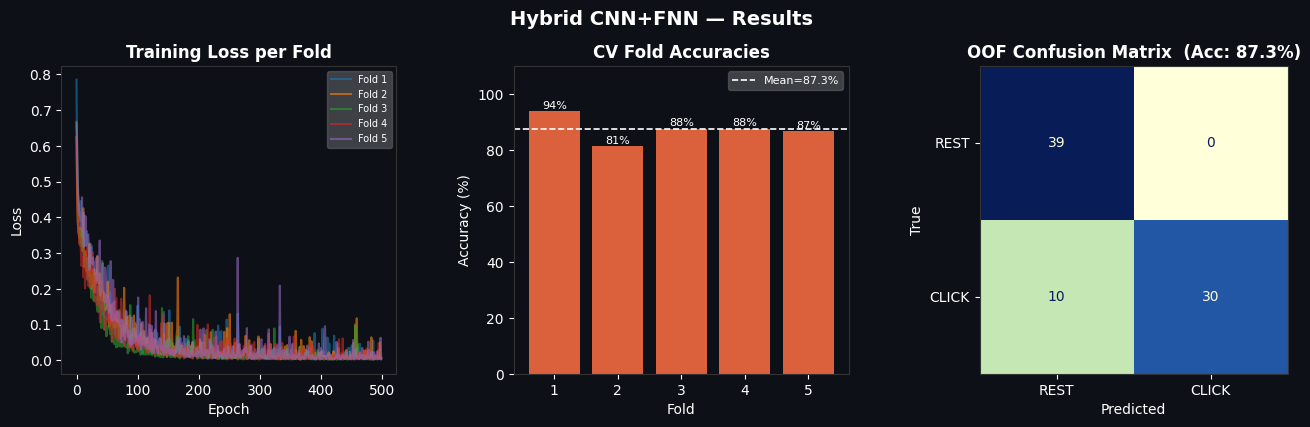

              precision    recall  f1-score   support

        REST       0.80      1.00      0.89        39
       CLICK       1.00      0.75      0.86        40

    accuracy                           0.87        79
   macro avg       0.90      0.88      0.87        79
weighted avg       0.90      0.87      0.87        79



In [51]:
plot_results('Hybrid CNN+FNN', hybrid_accs, hybrid_true, hybrid_pred, hybrid_loss_hist, color='#FF7043')

## Model Comparison

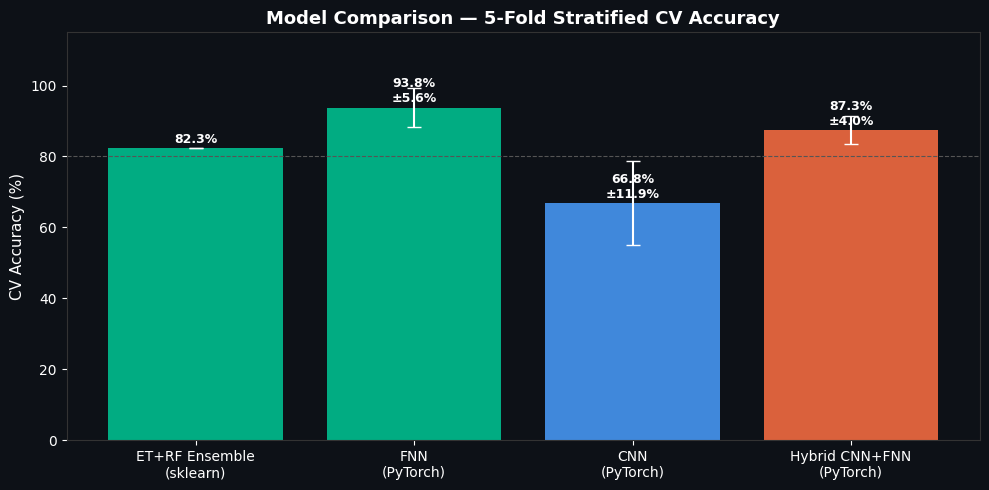

In [52]:
# ── Summary comparison across all models ─────────────────────────────────────
from sklearn.metrics import accuracy_score

# Also compute sklearn ensemble OOF accuracy for a fair comparison
from sklearn.model_selection import cross_val_predict
# Map y back to binary for sklearn ensemble (it uses the original label encoding)
y_sk_pred = cross_val_predict(
    ensemble, X_scaled, y_bin, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)
)
sk_acc = accuracy_score(y_bin, y_sk_pred)

models = ['ET+RF Ensemble\n(sklearn)', 'FNN\n(PyTorch)', 'CNN\n(PyTorch)', 'Hybrid CNN+FNN\n(PyTorch)']
accs   = [sk_acc,
          np.mean(fnn_accs),
          np.mean(cnn_accs),
          np.mean(hybrid_accs)]
stds   = [0.0,
          np.std(fnn_accs),
          np.std(cnn_accs),
          np.std(hybrid_accs)]
colors_bar = ['#00C896', '#00C896', '#4A9EFF', '#FF7043']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
for spine in ax.spines.values(): spine.set_color('#333')
ax.tick_params(colors='white')

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, [a*100 for a in accs], color=colors_bar, alpha=0.85,
              yerr=[s*100 for s in stds], capsize=5, error_kw=dict(ecolor='white', lw=1.5))
ax.set_xticks(x_pos)
ax.set_xticklabels(models, color='white', fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('CV Accuracy (%)', color='white', fontsize=11)
ax.set_title('Model Comparison — 5-Fold Stratified CV Accuracy', color='white', fontsize=13, fontweight='bold')
ax.axhline(80, color='#555', linestyle='--', linewidth=0.8)

for bar, acc, std in zip(bars, accs, stds):
    label = f'{acc*100:.1f}%' + (f'\n±{std*100:.1f}%' if std > 0 else '')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            label, ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Saving PyTorch Models

In [53]:
# ── Re-train on the full dataset and save all three PyTorch models ────────────

def train_full(build_fn, build_dataset_fn, epochs=120, lr=5e-4, batch_size=16):
    model = build_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ds = build_dataset_fn(np.arange(len(y_bin)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    for ep in range(epochs):
        train_epoch(model, loader, criterion, optimizer)
        scheduler.step()
    return model

print('Re-training on full dataset...')

fnn_full    = train_full(lambda: BCIFNN(in_features=N_FEATURES),
                         fnn_dataset, epochs=120, lr=1e-3)
cnn_full    = train_full(lambda: BCICNN(win_len=WIN_LEN),
                         cnn_dataset, epochs=120, lr=5e-4)
hybrid_full = train_full(lambda: BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES),
                         hybrid_dataset, epochs=120, lr=5e-4)

torch.save(fnn_full.state_dict(),    'BCI_FNN.pt')
torch.save(cnn_full.state_dict(),    'BCI_CNN.pt')
torch.save(hybrid_full.state_dict(), 'BCI_Hybrid.pt')

print('Saved: BCI_FNN.pt | BCI_CNN.pt | BCI_Hybrid.pt')

Re-training on full dataset...
Saved: BCI_FNN.pt | BCI_CNN.pt | BCI_Hybrid.pt


In [54]:
# ── Loading demo ──────────────────────────────────────────────────────────────
fnn_loaded = BCIFNN(in_features=N_FEATURES).to(DEVICE)
fnn_loaded.load_state_dict(torch.load('BCI_FNN.pt', map_location=DEVICE))
fnn_loaded.eval()

cnn_loaded = BCICNN(win_len=WIN_LEN).to(DEVICE)
cnn_loaded.load_state_dict(torch.load('BCI_CNN.pt', map_location=DEVICE))
cnn_loaded.eval()

hybrid_loaded = BCIHybrid(win_len=WIN_LEN, n_feat=N_FEATURES).to(DEVICE)
hybrid_loaded.load_state_dict(torch.load('BCI_Hybrid.pt', map_location=DEVICE))
hybrid_loaded.eval()

print('All three PyTorch models loaded successfully!')

# Quick inference example on the first sample
sample_raw  = torch.tensor(X_raw[[0]]).to(DEVICE)
sample_feat = torch.tensor(X_feat[[0]]).to(DEVICE)
LABEL_NAMES = {0: 'REST', 1: 'CLICK'}

with torch.no_grad():
    fnn_out    = fnn_loaded(sample_feat).argmax(1).item()
    cnn_out    = cnn_loaded(sample_raw).argmax(1).item()
    hybrid_out = hybrid_loaded(sample_raw, sample_feat).argmax(1).item()

print(f'\nSample 0  |  True: {LABEL_NAMES[y_bin[0]]}')
print(f'  FNN    prediction : {LABEL_NAMES[fnn_out]}')
print(f'  CNN    prediction : {LABEL_NAMES[cnn_out]}')
print(f'  Hybrid prediction : {LABEL_NAMES[hybrid_out]}')

All three PyTorch models loaded successfully!

Sample 0  |  True: CLICK
  FNN    prediction : CLICK
  CNN    prediction : REST
  Hybrid prediction : CLICK


In [55]:
import joblib
joblib.dump(scaler, 'BCI_SCALER.joblib')

['BCI_SCALER.joblib']

In [56]:
import joblib

# 1. Your model definition (example)
# ensemble = RandomForestClassifier() or similar

# 2. TRAIN THE MODEL (The missing step)
# This teaches the model using your data (X_scaled) and labels (y_bin)
ensemble.fit(X_scaled, y_bin) 

# 3. Save the model
# Only now is it safe to save, because the model has "learned" the patterns
joblib.dump(ensemble, 'BCI_MODEL.joblib')

print("Model fitted and saved successfully.")

Model fitted and saved successfully.
